# data

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path
import calendar

START = "2016-06-01"
END   = "2025-06-30"

# START = "2024-09-01"
# END = "2025-06-30"

In [2]:
import os
import glob
import pandas as pd

PORT_DIR = "../responses_portfolios"

def _find_date_col(df: pd.DataFrame) -> str:
    for c in ["date_key", "Date", "date", "ym"]:
        if c in df.columns:
            return c
    # fallback: first unnamed index column
    if len(df.columns) > 0 and str(df.columns[0]).lower().startswith("unnamed"):
        df = df.rename(columns={df.columns[0]: "date_key"})
        return "date_key"
    raise ValueError(f"Aucune colonne de date trouvée. Colonnes: {list(df.columns)}")

def _read_and_standardize(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    date_col = _find_date_col(df)

    # Standardize to 'date_key' as datetime
    if date_col == "ym":
        # 'YYYY-MM' -> month start
        df["date_key"] = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        df["date_key"] = pd.to_datetime(df[date_col], errors="coerce")

    # drop original date cols (except date_key)
    drop_cols = [c for c in ["Date", "date", "ym"] if c in df.columns and c != "date_key"]
    df = df.drop(columns=drop_cols, errors="ignore")

    # keep only rows with date
    df = df.dropna(subset=["date_key"]).copy()
    return df

def combine_monthly_portfolios(
    pattern: str,
    out_path: str,
) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(PORT_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé avec le pattern: {PORT_DIR}/{pattern}")

    dfs = []
    for f in files:
        df = _read_and_standardize(f)
        df["source_file"] = os.path.basename(f)  # pratique pour debug
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # sort & drop duplicates by date (keep last)
    out = out.sort_values("date_key")
    out = out.drop_duplicates(subset=["date_key"], keep="last").reset_index(drop=True)

    # save combined
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    out.to_csv(out_path, index=False)
    return out

# ---- Build combined baseline files ----
eq_combined = combine_monthly_portfolios(
    pattern="equal_weighted_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"),
)

opt_combined = combine_monthly_portfolios(
    pattern="optimized_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "optimized_portfolio.csv"),
)

print("Baselines combinés :")
print(" -", os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"), "(", len(eq_combined), "rows )")
print(" -", os.path.join(PORT_DIR, "optimized_portfolio.csv"), "(", len(opt_combined), "rows )")
display(eq_combined.head())
display(opt_combined.head())


Baselines combinés :
 - ../responses_portfolios\equal_weighted_portfolio.csv ( 125 rows )
 - ../responses_portfolios\optimized_portfolio.csv ( 125 rows )


,Portfolio_Return,date_key,source_file
0,0.052302,2015-02-01,equal_weighted_portfolio_2015-01-01_2015-01-31...
1,-0.026137,2015-03-01,equal_weighted_portfolio_2015-02-01_2015-02-28...
2,0.031671,2015-04-01,equal_weighted_portfolio_2015-03-01_2015-03-31...
3,0.006735,2015-05-01,equal_weighted_portfolio_2015-04-01_2015-04-30...
4,-0.025121,2015-06-01,equal_weighted_portfolio_2015-05-01_2015-05-31...


,Portfolio_Return,date_key,source_file
0,0.052302,2015-02-01,optimized_portfolio_2015-01-01_2015-01-31.csv
1,-0.026137,2015-03-01,optimized_portfolio_2015-02-01_2015-02-28.csv
2,0.031671,2015-04-01,optimized_portfolio_2015-03-01_2015-03-31.csv
3,0.006735,2015-05-01,optimized_portfolio_2015-04-01_2015-04-30.csv
4,-0.025121,2015-06-01,optimized_portfolio_2015-05-01_2015-05-31.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
Baselines portfolio returns (generated by baselines.py)
Expected files:
  - responses_portfolios/equal_weighted_portfolio.csv
  - responses_portfolios/optimized_portfolio.csv
"""
equal_weighted_portfolio_returns = pd.read_csv('../responses_portfolios/equal_weighted_portfolio.csv')
optimized_portfolio_returns      = pd.read_csv('../responses_portfolios/optimized_portfolio.csv')

equal_weighted_portfolio_returns.head()
optimized_portfolio_returns.tail()


,Portfolio_Return,date_key,source_file
120,-0.023477,2025-02-01,optimized_portfolio.csv
121,-0.101440,2025-03-01,optimized_portfolio.csv
122,-0.007443,2025-04-01,optimized_portfolio.csv
123,0.039691,2025-05-01,optimized_portfolio.csv
124,0.005713,2025-06-01,optimized_portfolio_2025-05-01_2025-05-31.csv


# Chargement des nouveaux portefeuilles Black-Litterman

Cette version du notebook prend en entrée les fichiers générés par `blacklitterman_weights_recommended_variants.py` et les fichiers de rendements générés ensuite par `returns_from_weights.py`.


In [4]:
import glob
import os
from pathlib import Path
import pandas as pd
import numpy as np

tau = 0.025
RESULTS_DIR = Path("../results")

# Les variantes principales recommandées.
# Ces noms doivent correspondre au préfixe utilisé dans les fichiers :
# results/{portfolio_id}_black_litterman_market_implied_weights_tau_{tau}.csv
# results/{portfolio_id}_black_litterman_implied_weights_returns_tau_{tau}_{START}_{END}.csv
BL_VARIANTS = {
    #"BL-None/no views": "none",

    # Gemma3 : versions principale/prudente/agressive
    "BL-Gemma3 blend 25%": "gemma3_blend_alpha_0.25_omega_1",
    "BL-Gemma3 blend 50%": "gemma3_blend_alpha_0.5_omega_1",
    "BL-Gemma3 omega x25": "gemma3_omega_x25",

    # GPT : versions principale/agressive
    "BL-GPT blend 50%": "gpt_blend_alpha_0.5_omega_1",
    "BL-GPT omega x25": "gpt_omega_x25",

    # Modèles moins performants dans les tests, conservés pour comparaison
    "BL-Llama blend 10%": "llama_blend_alpha_0.1_omega_1",
    "BL-Qwen blend 10%": "qwen_blend_alpha_0.1_omega_1",
}

# Variantes optionnelles si tu as lancé blacklitterman_weights_recommended_variants.py avec --include_rank.
# Le notebook les charge seulement si les fichiers existent.
OPTIONAL_BL_VARIANTS = {
    "BL-Gemma3 rank": "gemma3_rank_q0.3_strength_1_omega_10",
    "BL-GPT rank": "gpt_rank_q0.2_strength_1_omega_10",
}


def _find_existing_file(patterns, required=True, label="file"):
    candidates = []
    for pat in patterns:
        candidates.extend(sorted(glob.glob(str(pat))))
    candidates = sorted(set(candidates))
    if not candidates:
        if required:
            raise FileNotFoundError(
                f"Could not find {label}. Tried:\n" + "\n".join(f"- {p}" for p in patterns)
            )
        return None
    return candidates[-1]


def _read_weights_file(portfolio_id: str, required: bool = True) -> pd.DataFrame | None:
    patterns = [
        RESULTS_DIR / f"{portfolio_id}_black_litterman_market_implied_weights_tau_{tau}.csv",
        RESULTS_DIR / f"{portfolio_id}_black_litterman_market_implied_weights_tau_{tau}_*.csv",
    ]
    path = _find_existing_file(patterns, required=required, label=f"weights for {portfolio_id}")
    if path is None:
        return None

    df = pd.read_csv(path)
    date_col = "Date" if "Date" in df.columns else ("date_key" if "date_key" in df.columns else df.columns[0])
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).set_index(date_col).sort_index()
    df.index = df.index.to_period("M").to_timestamp()
    df.attrs["source_path"] = path
    return df


def _read_returns_file(portfolio_id: str, required: bool = True) -> pd.DataFrame | None:
    patterns = [
        RESULTS_DIR / f"{portfolio_id}_black_litterman_implied_weights_returns_tau_{tau}_{START}_{END}.csv",
        RESULTS_DIR / f"{portfolio_id}_black_litterman_implied_weights_returns_tau_{tau}_*.csv",
        RESULTS_DIR / f"{portfolio_id}_black_litterman_implied_weights_returns_tau_{tau}.csv",
    ]
    path = _find_existing_file(patterns, required=required, label=f"returns for {portfolio_id}")
    if path is None:
        return None
    df = pd.read_csv(path)
    df.attrs["source_path"] = path
    return df


# Chargement des nouveaux BL principaux
bl_weights = {}
bl_returns = {}

for label, portfolio_id in BL_VARIANTS.items():
    w = _read_weights_file(portfolio_id, required=(portfolio_id != "none"))
    r = _read_returns_file(portfolio_id, required=True)
    if w is not None:
        bl_weights[label] = w
    bl_returns[label] = r
    print(f"{label:25s} | id={portfolio_id:40s} | returns={r.attrs.get('source_path')}")

# Chargement optionnel des variantes rank-based
for label, portfolio_id in OPTIONAL_BL_VARIANTS.items():
    w = _read_weights_file(portfolio_id, required=False)
    r = _read_returns_file(portfolio_id, required=False)
    if r is not None:
        if w is not None:
            bl_weights[label] = w
        bl_returns[label] = r
        print(f"{label:25s} | id={portfolio_id:40s} | returns={r.attrs.get('source_path')} [optional loaded]")
    else:
        print(f"{label:25s} | id={portfolio_id:40s} | optional file not found, skipped")

print(f"\nNombre de portefeuilles BL chargés: {len(bl_returns)}")


BL-Gemma3 blend 25%       | id=gemma3_blend_alpha_0.25_omega_1          | returns=..\results\gemma3_blend_alpha_0.25_omega_1_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv
BL-Gemma3 blend 50%       | id=gemma3_blend_alpha_0.5_omega_1           | returns=..\results\gemma3_blend_alpha_0.5_omega_1_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv
BL-Gemma3 omega x25       | id=gemma3_omega_x25                         | returns=..\results\gemma3_omega_x25_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv
BL-GPT blend 50%          | id=gpt_blend_alpha_0.5_omega_1              | returns=..\results\gpt_blend_alpha_0.5_omega_1_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv
BL-GPT omega x25          | id=gpt_omega_x25                            | returns=..\results\gpt_omega_x25_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv
BL-Llama blend 10%        | id=ll

In [5]:
"""
S&P 500 proxy returns (monthly) from data ETF (e.g., SPY):
- Download daily adjusted prices
- Convert to monthly returns (month-end to month-end)
- Keep Jan..Jun 2025 inclusive
"""
import pandas as pd

try:
    import yfinance as yf
except ImportError:
    raise ImportError("data n'est pas installé. Fais: pip install data")

ETF = "SPY"

px = yf.download(ETF, start=START, end=END, progress=False)
if px.empty:
    raise ValueError(f"No data downloaded for {ETF}. Check internet access / ticker.")

# Prefer Adj Close if available, else Close
if "Adj Close" in px.columns:
    close = px["Adj Close"]
else:
    close = px["Close"]

# If DataFrame (edge case), take first column
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

close = close.dropna()

# Month-end close and monthly returns
m_close = close.resample("ME").last()
m_ret = m_close.pct_change().dropna()

sp500_proxy = pd.DataFrame({
    "date_key": m_ret.index,
    "Portfolio_Return": m_ret.values
})

# Keep months end Jan..Jun 2023
sp500_proxy = sp500_proxy[(sp500_proxy["date_key"] >= START) & (sp500_proxy["date_key"] <= END)].copy()
sp500_proxy


C:\Users\alexi\AppData\Local\Temp\ipykernel_16928\1197347073.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(ETF, start=START, end=END, progress=False)


,date_key,Portfolio_Return
0,2016-07-31,0.036471
1,2016-08-31,0.001198
2,2016-09-30,0.000058
3,2016-10-31,-0.017337
4,2016-11-30,0.036838
...,...,...
103,2025-02-28,-0.012695
104,2025-03-31,-0.055719
105,2025-04-30,-0.008670
106,2025-05-31,0.062845


In [6]:
"""
S&P25 proxy returns (monthly) from local filtered_sp25_data.csv.

The dataset already contains the time-varying S&P25 universe. The portfolio
return is calculated as a cap-weighted return using market_equity.

Important financial convention:
- for month t, weights are based on market_equity observed at t-1;
- then those weights are applied to stock_ret observed in month t;
- weights are renormalized across tickers that have both a valid lagged cap and
  a valid realized return in month t.

This avoids using end-of-month market caps to weight the same month's return.
"""
import pandas as pd
import numpy as np

SP25_DATA_PATH = "../data/filtered_sp25_data.csv"


def _build_sp25_cap_weighted_returns(
    csv_path: str = SP25_DATA_PATH,
    start: str = START,
    end: str = END,
) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False).copy()

    required = {"tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"filtered_sp25_data.csv missing columns: {sorted(missing)}")

    # --- Date parsing ---
    if "date" in df.columns:
        # Handles YYYYMMDD integers/strings and normal date strings.
        s = df["date"]
        if pd.api.types.is_numeric_dtype(s):
            df["date_key"] = pd.to_datetime(s.astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
        else:
            ss = s.astype(str).str.strip()
            looks_yyyymmdd = ss.str.match(r"^\d{8}$")
            df["date_key"] = pd.NaT
            df.loc[looks_yyyymmdd, "date_key"] = pd.to_datetime(ss.loc[looks_yyyymmdd], format="%Y%m%d", errors="coerce")
            df.loc[~looks_yyyymmdd, "date_key"] = pd.to_datetime(ss.loc[~looks_yyyymmdd], errors="coerce")
    elif {"year", "month"}.issubset(df.columns):
        df["date_key"] = pd.to_datetime(
            dict(
                year=pd.to_numeric(df["year"], errors="coerce"),
                month=pd.to_numeric(df["month"], errors="coerce"),
                day=1,
            ),
            errors="coerce",
        )
    else:
        raise ValueError("filtered_sp25_data.csv must contain either 'date' or both 'year' and 'month'.")

    df = df.dropna(subset=["date_key", "tic"]).copy()
    df["tic"] = (
        df["tic"].astype(str).str.strip().str.upper()
        .str.replace(r"\s+", "", regex=True)
        .str.replace("-", ".", regex=False)
    )
    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df["ym"] = df["date_key"].dt.to_period("M")

    # Keep the last available observation per ticker-month.
    monthly = (
        df.sort_values(["ym", "tic", "date_key"])
          .drop_duplicates(subset=["ym", "tic"], keep="last")
    )

    ret = monthly.pivot(index="ym", columns="tic", values="stock_ret").sort_index()
    cap = monthly.pivot(index="ym", columns="tic", values="market_equity").sort_index()

    # Lag market caps by one month to build investable start-of-month weights.
    cap_lag = cap.shift(1)

    sp25_returns = []
    for ym in ret.index:
        r = ret.loc[ym]
        caps = cap_lag.loc[ym]

        valid = r.notna() & caps.notna() & np.isfinite(r) & np.isfinite(caps) & (caps > 0)
        if valid.sum() < 2:
            continue

        w = caps.loc[valid] / caps.loc[valid].sum()
        port_ret = float((r.loc[valid] * w).sum())

        sp25_returns.append({
            "date_key": ym.to_timestamp(),
            "Portfolio_Return": port_ret,
            "n_assets": int(valid.sum()),
        })

    out = pd.DataFrame(sp25_returns)
    out = out[(out["date_key"] >= pd.to_datetime(start)) & (out["date_key"] <= pd.to_datetime(end))].copy()
    return out.reset_index(drop=True)


sp25_proxy = _build_sp25_cap_weighted_returns()
print(
    f"S&P25 cap-weighted proxy: {sp25_proxy['date_key'].min().date()} -> "
    f"{sp25_proxy['date_key'].max().date()} | {len(sp25_proxy)} mois"
)
display(sp25_proxy.head())
display(sp25_proxy.tail())



S&P25 cap-weighted proxy: 2016-06-01 -> 2025-06-01 | 109 mois


,date_key,Portfolio_Return,n_assets
0,2016-06-01,0.005321,22
1,2016-07-01,0.037282,23
2,2016-08-01,0.003355,24
3,2016-09-01,0.005031,23
4,2016-10-01,-0.013710,24


,date_key,Portfolio_Return,n_assets
104,2025-02-01,0.005024,21
105,2025-03-01,-0.080562,21
106,2025-04-01,-0.000016,24
107,2025-05-01,0.073087,24
108,2025-06-01,0.069503,23


# evaluate

In [7]:
import numpy as np
import pandas as pd

def _standardize_returns(df: pd.DataFrame, name: str) -> pd.Series:
    """
    Accepts df with 'Portfolio_Return' and one date column among: date_key / Date / ym.
    Returns a Series indexed by datetime at MONTH START (YYYY-MM-01).
    """
    df = df.copy()

    if "date_key" in df.columns:
        dt = pd.to_datetime(df["date_key"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    elif "ym" in df.columns:
        dt = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        raise ValueError(f"{name}: could not find a date column in {list(df.columns)}")

    if "Portfolio_Return" not in df.columns:
        raise ValueError(f"{name}: missing 'Portfolio_Return' column")

    s = pd.Series(pd.to_numeric(df["Portfolio_Return"], errors="coerce").values, index=dt)
    s = s.dropna()
    s.index = s.index.to_period("M").to_timestamp()
    s = s[~s.index.duplicated(keep="last")].sort_index()
    return s


def _infer_periods_per_year(index: pd.DatetimeIndex) -> int:
    return 12

# Séries de base
r_sp500 = _standardize_returns(sp500_proxy, "SP500 proxy")
r_sp25  = _standardize_returns(sp25_proxy, "S&P25 cap-weighted proxy")
r_ew    = _standardize_returns(equal_weighted_portfolio_returns, "EW")
r_mvo   = _standardize_returns(optimized_portfolio_returns, "MVO")

# Séries BL recommandées
r_bl = {
    label: _standardize_returns(df, label)
    for label, df in bl_returns.items()
}

# Portefeuilles à comparer
portfolios = {
    "SP500 (SPY)": r_sp500,
    "S&P25 cap-weighted": r_sp25,
    "EW": r_ew,
    #"MVO": r_mvo,
}
portfolios.update(r_bl)

# Alignement sur la période commune à tous les portefeuilles chargés.
common_idx = None
for name, s in portfolios.items():
    common_idx = s.index if common_idx is None else common_idx.intersection(s.index)

common_idx = pd.DatetimeIndex(common_idx).sort_values()

# Restreindre toutes les séries à l'index commun.
for name in list(portfolios.keys()):
    portfolios[name] = portfolios[name].loc[common_idx]

print(f"Période commune: {common_idx.min().date()} -> {common_idx.max().date()} | {len(common_idx)} mois")
print("Portefeuilles inclus:")
for name in portfolios:
    print("-", name)


Période commune: 2016-07-01 -> 2025-06-01 | 108 mois
Portefeuilles inclus:
- SP500 (SPY)
- S&P25 cap-weighted
- EW
- BL-Gemma3 blend 25%
- BL-Gemma3 blend 50%
- BL-Gemma3 omega x25
- BL-GPT blend 50%
- BL-GPT omega x25
- BL-Llama blend 10%
- BL-Qwen blend 10%


In [8]:
import numpy as np
import pandas as pd

RISK_FREE_CSV = "../data/DGS1.csv"
BENCHMARK_NAME = "S&P25 cap-weighted"  # plus logique pour les portefeuilles construits sur l'univers S&P25

def load_risk_free_monthly_annual(csv_path: str) -> pd.Series:
    """
    Load FRED-style CSV (DATE/observation_date, DGS1/DGS10/...) where yield is in percent,
    return a month-end series of annualized yields in decimal.
    """
    df = pd.read_csv(csv_path)

    date_col = next((c for c in df.columns if c.lower() in {"date", "observation_date"}), df.columns[0])
    val_col  = next((c for c in df.columns if c.lower() != date_col.lower()), df.columns[1])

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[val_col]  = pd.to_numeric(df[val_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    s = df.set_index(date_col)[val_col] / 100.0
    s = s.resample("ME").last()
    return s

ppy = _infer_periods_per_year(common_idx)
rf_annual_m = load_risk_free_monthly_annual(RISK_FREE_CSV)

idx_month = pd.DatetimeIndex(common_idx).to_period("M")
rf_month = rf_annual_m.copy()
rf_month.index = rf_month.index.to_period("M")
rf_annual_aligned = rf_month.reindex(idx_month).ffill().bfill()
rf_annual_aligned.index = common_idx
rf_per_period = rf_annual_aligned / float(ppy)

stats = {}
benchmark_returns = portfolios[BENCHMARK_NAME].reindex(common_idx).astype(float)

for name, returns in portfolios.items():
    ret = returns.reindex(common_idx).astype(float)

    cum = (1 + ret).prod() - 1
    n_periods = max(1, len(ret))
    cagr = (1 + cum) ** (1 / (n_periods / float(ppy))) - 1
    ann_vol = ret.std(ddof=1) * np.sqrt(ppy)

    excess = ret - rf_per_period
    denom = ret.std(ddof=1)
    sharpe = (excess.mean() / denom) * np.sqrt(ppy) if denom > 0 else np.nan

    active = ret - benchmark_returns
    tracking_error = active.std(ddof=1) * np.sqrt(ppy)
    info_ratio = (active.mean() * ppy / tracking_error) if tracking_error > 0 else np.nan
    ann_active_return = active.mean() * ppy

    var_q = ret.quantile(0.05)
    var_95 = -var_q
    cvar_95 = -ret[ret <= var_q].mean()

    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    mdd = dd.min()

    stats[name] = {
        "Cum. Return": round(float(cum), 4),
        "CAGR": round(float(cagr), 4),
        "Ann. Vol": round(float(ann_vol), 4),
        "Sharpe": round(float(sharpe), 4),
        f"Ann. Active Return vs {BENCHMARK_NAME}": round(float(ann_active_return), 4),
        f"Tracking Error vs {BENCHMARK_NAME}": round(float(tracking_error), 4),
        f"Info Ratio vs {BENCHMARK_NAME}": round(float(info_ratio), 4),
        "VaR 95%": round(float(var_95), 4),
        "CVaR 95%": round(float(cvar_95), 4),
        "Max Drawdown": round(float(mdd), 4),
    }

stats_df = pd.DataFrame(stats).T.sort_values("CAGR", ascending=False)
print(f"Periods/year inferred: {ppy}")
stats_df


Periods/year inferred: 12


,Cum. Return,CAGR,Ann. Vol,Sharpe,Ann. Active Return vs S&P25 cap-weighted,Tracking Error vs S&P25 cap-weighted,Info Ratio vs S&P25 cap-weighted,VaR 95%,CVaR 95%,Max Drawdown
BL-Gemma3 omega x25,12.0051,0.3298,0.2738,1.0994,0.1335,0.1702,0.7845,0.0945,0.1187,-0.3859
BL-GPT omega x25,9.4269,0.2976,0.2778,0.9968,0.1094,0.1659,0.6595,0.1048,0.1195,-0.4311
BL-Gemma3 blend 50%,8.2773,0.2808,0.2209,1.1335,0.0830,0.1030,0.8061,0.0821,0.1050,-0.2873
BL-Gemma3 blend 25%,5.7351,0.2361,0.1914,1.0887,0.0409,0.0515,0.7941,0.0794,0.0970,-0.2711
BL-GPT blend 50%,5.5409,0.2320,0.2411,0.8936,0.0480,0.1182,0.4061,0.0986,0.1149,-0.4277
S&P25 cap-weighted,3.8268,0.1911,0.1725,0.9707,0.0000,0.0000,NaN,0.0805,0.0897,-0.2854
BL-Qwen blend 10%,3.7338,0.1886,0.1759,0.9428,-0.0016,0.0235,-0.0676,0.0813,0.0915,-0.2843
BL-Llama blend 10%,3.2683,0.1750,0.1683,0.9083,-0.0146,0.0202,-0.7199,0.0761,0.0857,-0.2774
EW,2.7781,0.1592,0.1497,0.9101,-0.0312,0.0575,-0.5418,0.0658,0.0832,-0.2368
SP500 (SPY),2.4083,0.1460,0.1560,0.8058,-0.0418,0.0621,-0.6723,0.0756,0.0925,-0.2393


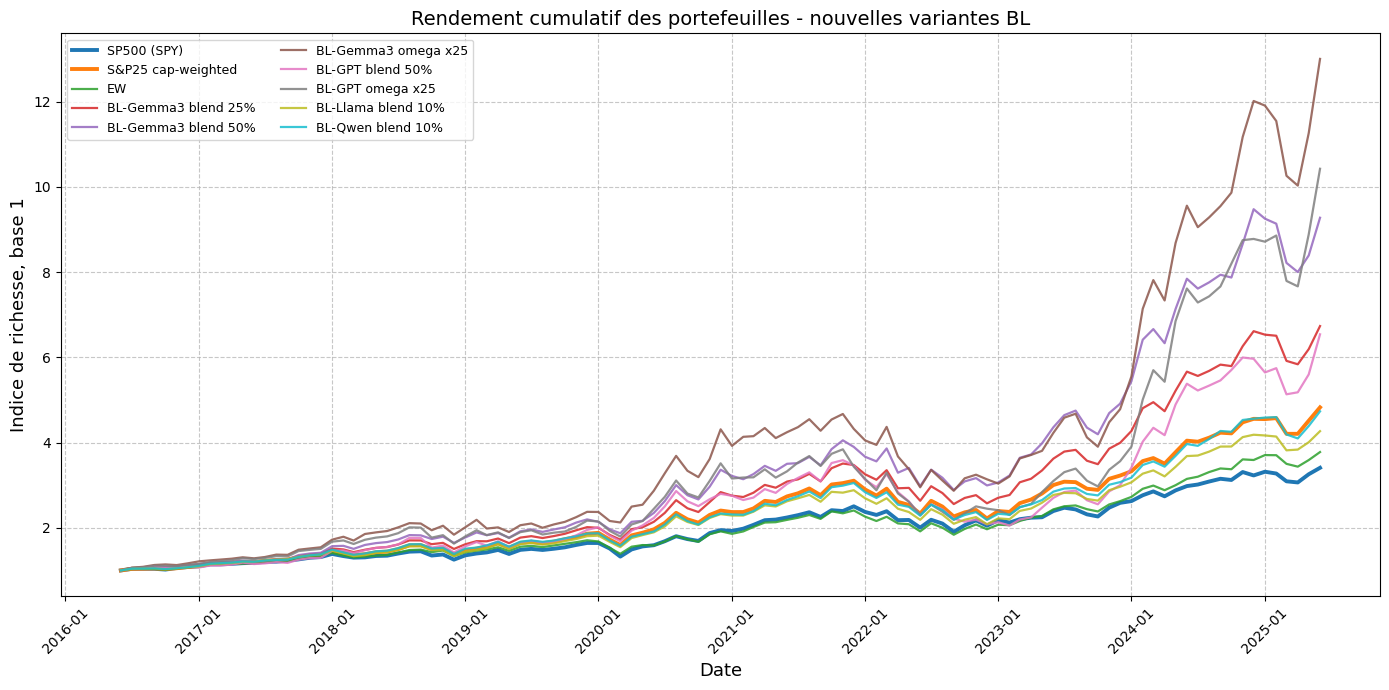

In [9]:
import matplotlib.pyplot as plt
import matplotlib

plt.figure(figsize=(14, 7))

for name, returns in portfolios.items():
    ret = returns.reindex(common_idx).dropna().astype(float)
    wealth = (1 + ret).cumprod()

    first_date = wealth.index[0]
    initial_date = first_date - pd.offsets.MonthBegin(1)
    wealth = pd.concat([
        pd.Series([1.0], index=[initial_date]),
        wealth
    ])

    # Mettre les benchmarks un peu plus en évidence
    lw = 2.8 if name in {"S&P25 cap-weighted", "SP500 (SPY)"} else 1.6
    alpha = 1.0 if name in {"S&P25 cap-weighted", "SP500 (SPY)"} else 0.85
    plt.plot(wealth.index, wealth.values, label=name, linewidth=lw, alpha=alpha)

plt.grid(True, linestyle="--", alpha=0.7)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Indice de richesse, base 1", fontsize=13)
plt.title("Rendement cumulatif des portefeuilles - nouvelles variantes BL", fontsize=14)
plt.legend(loc="upper left", fontsize=9, ncol=2)

plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Benchmarks trouvés : ['S&P25 cap-weighted', 'SP500 (SPY)', 'EW']
Portefeuilles LLM trouvés :
- BL-Gemma3 blend 25%
- BL-Gemma3 blend 50%
- BL-Gemma3 omega x25
- BL-GPT blend 50%
- BL-GPT omega x25
- BL-Llama blend 10%
- BL-Qwen blend 10%


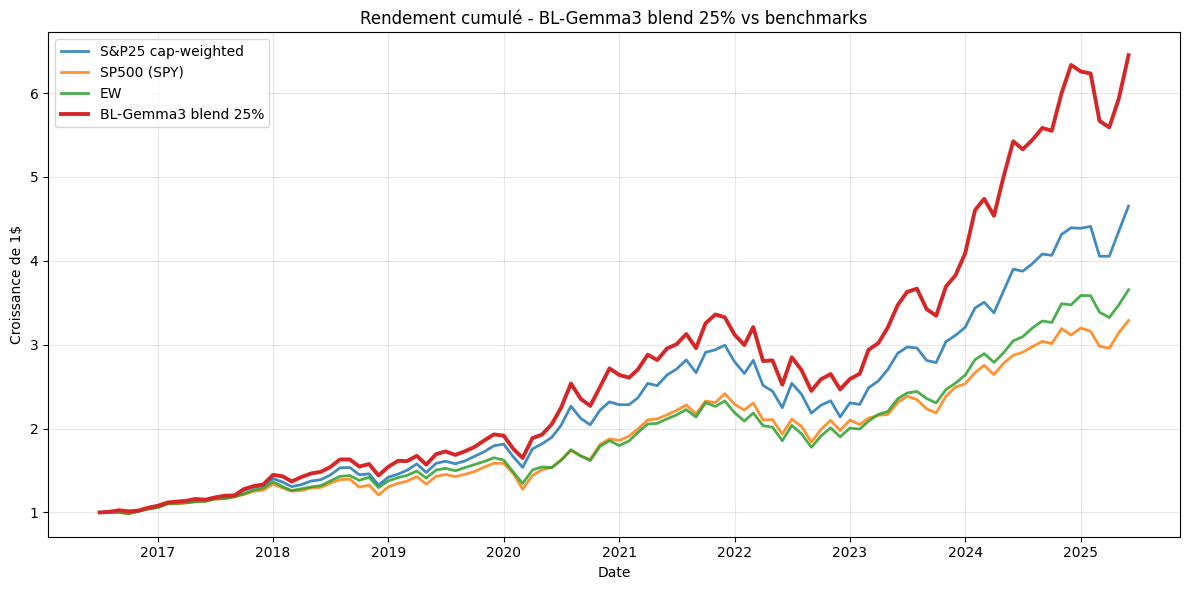

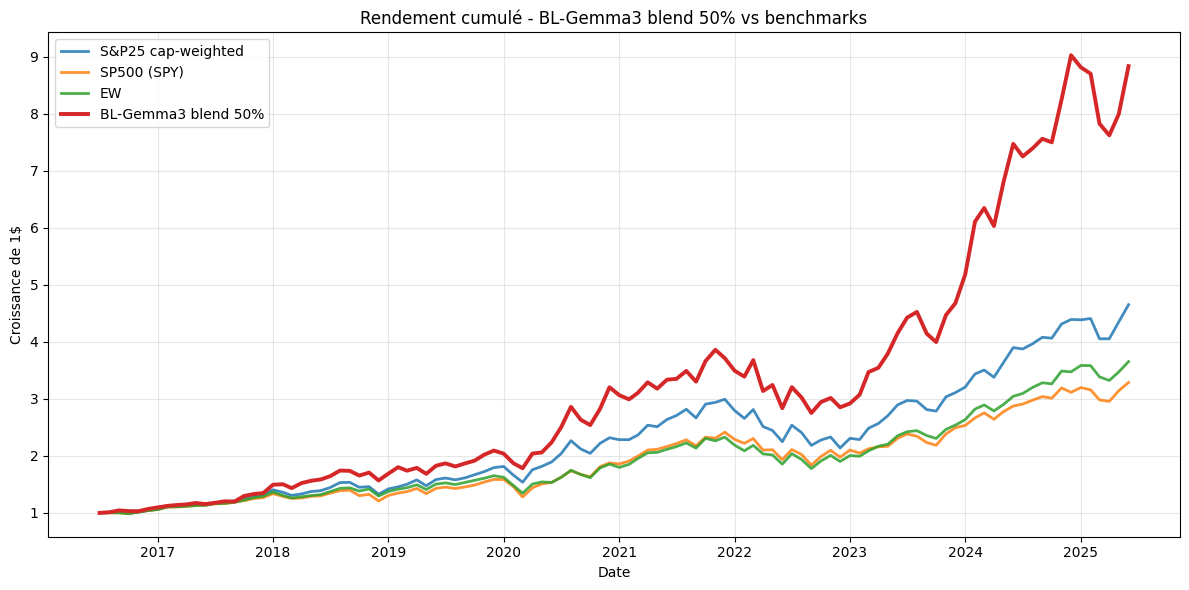

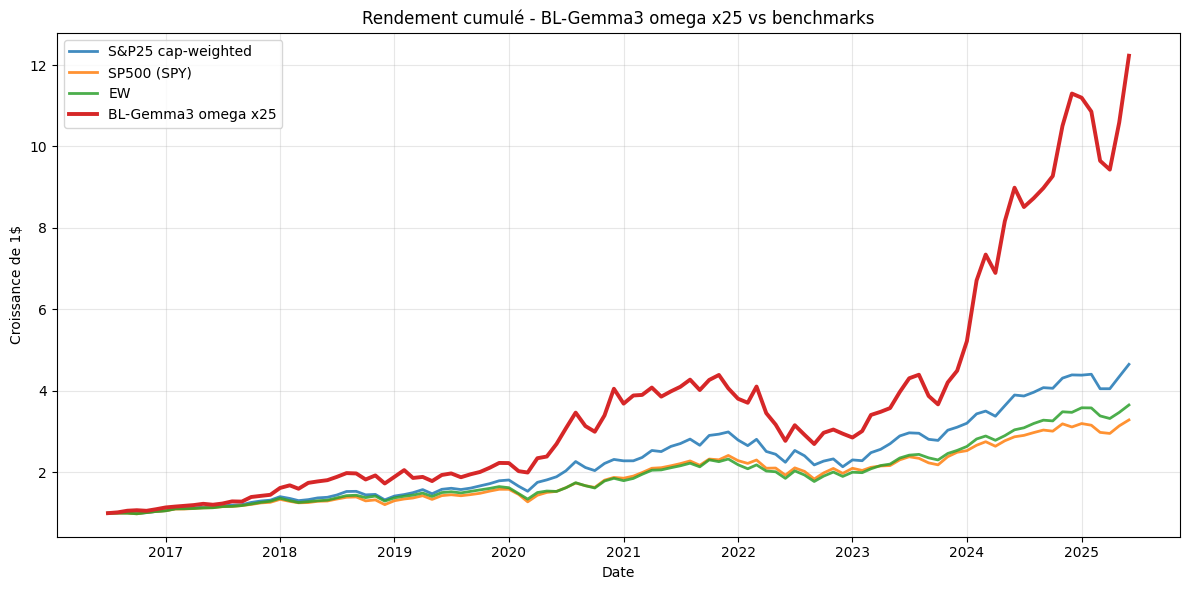

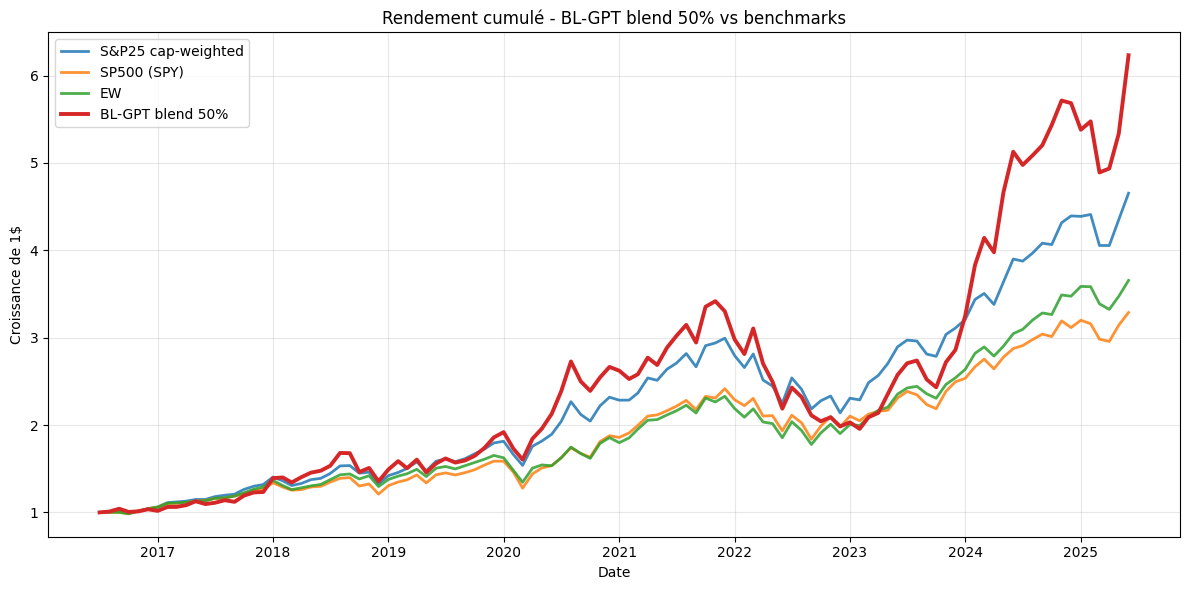

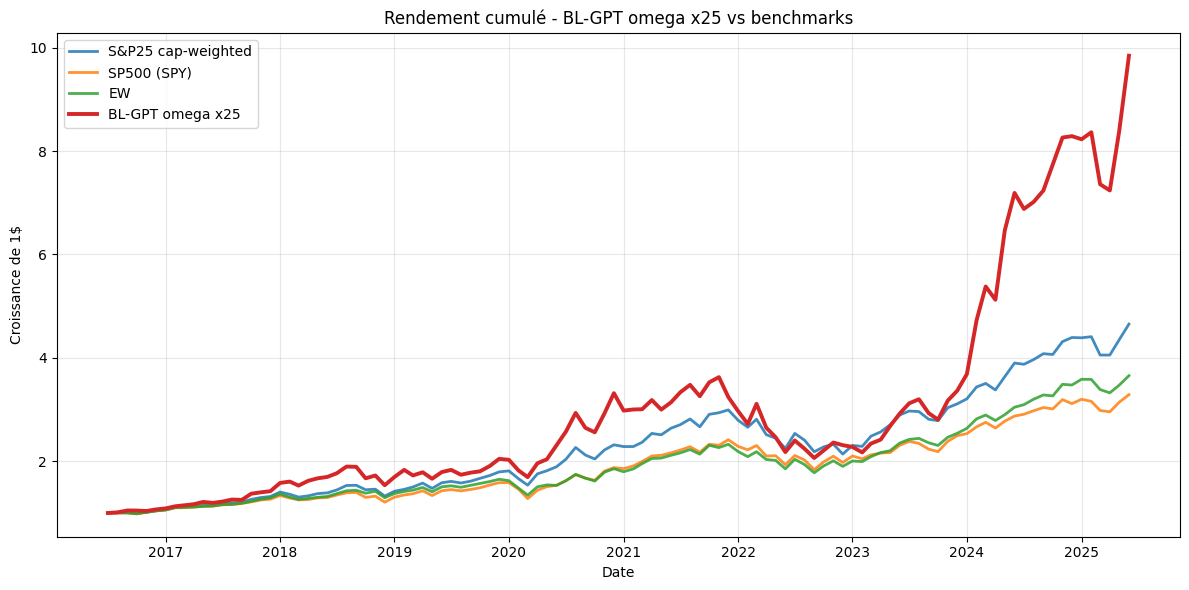

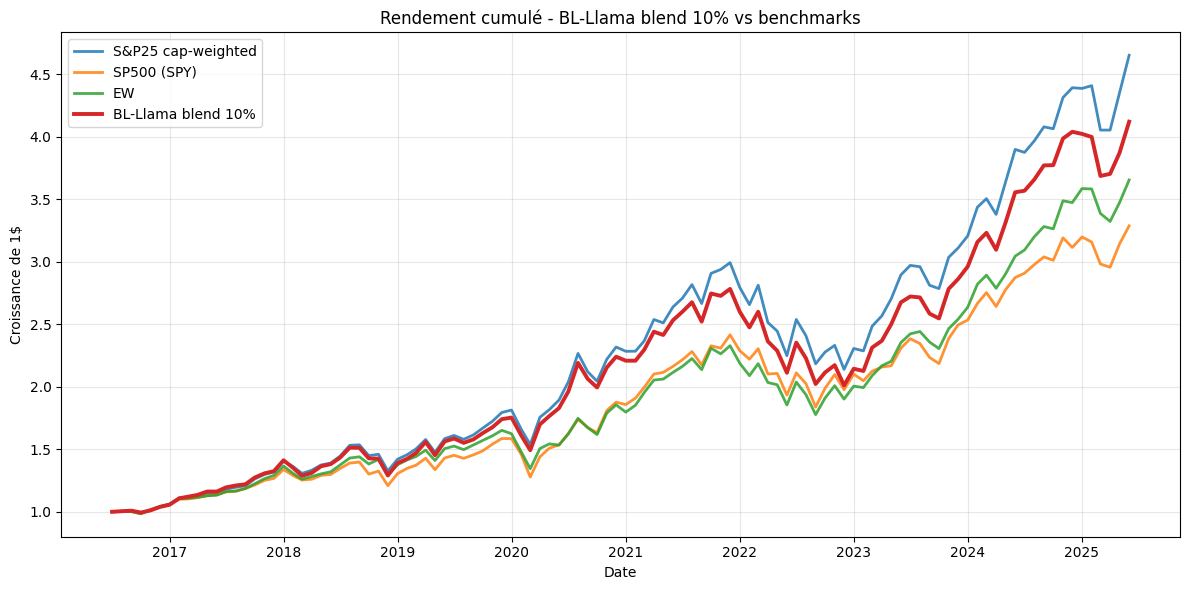

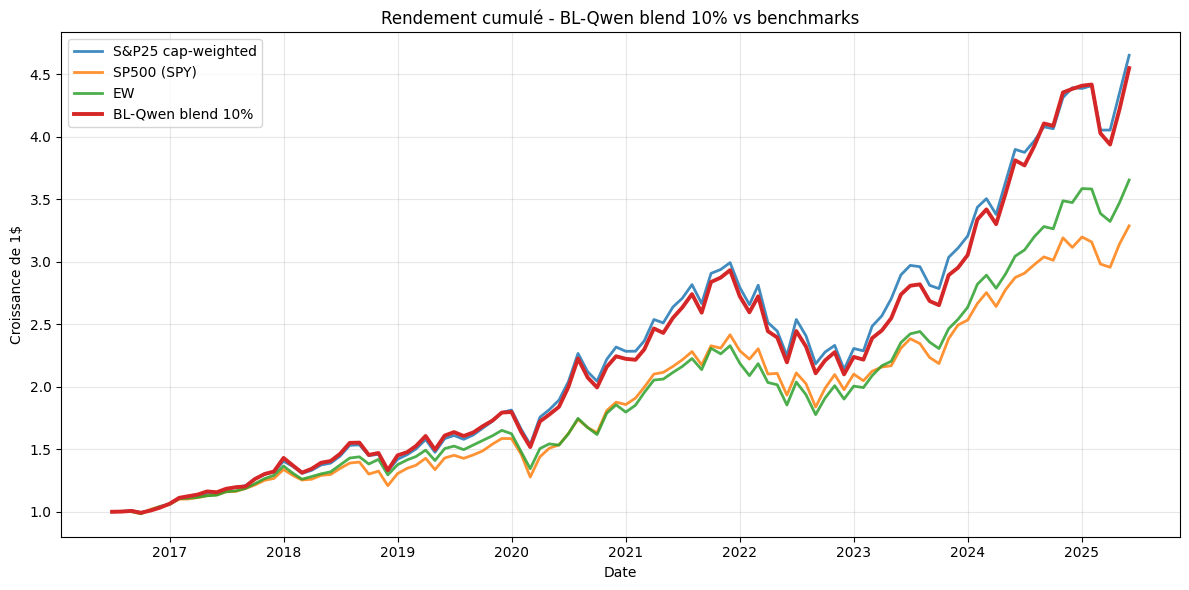

In [10]:
# ============================
# Graphiques individuels :
# 1 portefeuille LLM à la fois vs S&P25 / S&P500 / EW
# ============================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Identifier automatiquement les portefeuilles LLM
# --------------------------------------------------
benchmark_names = {
    "S&P25 cap-weighted",
    "S&P500",
    "SP500 (SPY)",
    "SPY",
    "EW",
    "Equal-weight",
    "Equal Weighted",
    "MVO",
    "BL-None/no views",
    "BL None/no views",
    "BL-None",
}

# On suppose que le notebook a déjà construit un dictionnaire `portfolios`
# du type : portfolios["Nom"] = pd.Series de rendements
if "portfolios" not in globals():
    raise ValueError("Le dictionnaire `portfolios` n'existe pas. Exécute les cellules précédentes du notebook.")

# Benchmarks à afficher s'ils existent dans le notebook
benchmark_candidates = [
    "S&P25 cap-weighted",
    "S&P500",
    "SP500 (SPY)",
    "SPY",
    "EW",
    "Equal-weight",
    "Equal Weighted",
]

available_benchmarks = [b for b in benchmark_candidates if b in portfolios]

print("Benchmarks trouvés :", available_benchmarks)

if len(available_benchmarks) == 0:
    raise ValueError("Aucun benchmark trouvé dans `portfolios`. Vérifie les noms utilisés dans le notebook.")

# Portefeuilles LLM = tout ce qui commence par BL mais qui n'est pas BL sans vues
llm_portfolios = [
    name for name in portfolios.keys()
    if (
        str(name).startswith("BL-")
        and "None" not in str(name)
        and "no views" not in str(name).lower()
    )
]

print("Portefeuilles LLM trouvés :")
for p in llm_portfolios:
    print("-", p)

if len(llm_portfolios) == 0:
    raise ValueError("Aucun portefeuille LLM trouvé. Vérifie que les noms commencent bien par `BL-`.")

# --------------------------------------------------
# 2. Fonction cumulatif base 1
# --------------------------------------------------
def cumulative_base_1(r: pd.Series) -> pd.Series:
    r = pd.Series(r).copy()
    r.index = pd.to_datetime(r.index)
    r = pd.to_numeric(r, errors="coerce").dropna()
    return (1.0 + r).cumprod()

# --------------------------------------------------
# 3. Plot : 1 graphique par portefeuille LLM
# --------------------------------------------------
for pf_name in llm_portfolios:
    series_to_plot = {}

    # Portefeuille LLM
    series_to_plot[pf_name] = cumulative_base_1(portfolios[pf_name])

    # Benchmarks
    for bench_name in available_benchmarks:
        series_to_plot[bench_name] = cumulative_base_1(portfolios[bench_name])

    # Alignement des dates communes pour que toutes les courbes commencent au même point
    common_index = None
    for s in series_to_plot.values():
        common_index = s.index if common_index is None else common_index.intersection(s.index)

    common_index = common_index.sort_values()

    if len(common_index) == 0:
        print(f"[SKIP] Aucun overlap de dates pour {pf_name}.")
        continue

    aligned = {
        name: s.reindex(common_index).dropna()
        for name, s in series_to_plot.items()
    }

    # Rebase à 1 sur la première date commune
    aligned = {
        name: s / s.iloc[0]
        for name, s in aligned.items()
        if len(s) > 0
    }

    plt.figure(figsize=(12, 6))

    # Benchmark d'abord
    for bench_name in available_benchmarks:
        if bench_name in aligned:
            plt.plot(
                aligned[bench_name].index,
                aligned[bench_name].values,
                label=bench_name,
                linewidth=2.0,
                alpha=0.85,
            )

    # Portefeuille LLM en dernier pour qu'il soit visible
    plt.plot(
        aligned[pf_name].index,
        aligned[pf_name].values,
        label=pf_name,
        linewidth=2.8,
    )

    plt.title(f"Rendement cumulé - {pf_name} vs benchmarks")
    plt.xlabel("Date")
    plt.ylabel("Croissance de 1$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Métriques de viabilité financière des portefeuilles BL

Cette section ajoute des métriques basées sur les poids : active share vs S&P25, nombre de titres non nuls, concentration, turnover, poids top 5 et indicateurs simples de viabilité.



In [ ]:

# ============================
# Métriques de viabilité financière basées sur les poids
# Active share, concentration, turnover, nombre de titres non nuls
# ============================

import numpy as np
import pandas as pd
from pathlib import Path

WEIGHT_EPS = 1e-6
SP25_DATA_PATH = "../data/filtered_sp25_data.csv"

# --------------------------------------------------
# 1. Helpers de nettoyage / alignement des poids
# --------------------------------------------------
def _clean_ticker_local(x) -> str:
    if x is None:
        return ""
    s = str(x).strip().strip('"').strip("'").upper()
    if not s or s in {"NAN", "NONE"}:
        return ""
    s = s.replace("-", ".")
    s = "".join(s.split())
    return s


def _parse_date_series_local(s: pd.Series) -> pd.Series:
    """Parse robuste pour dates YYYYMMDD, string ou datetime."""
    if pd.api.types.is_numeric_dtype(s):
        ss = pd.to_numeric(s, errors="coerce").astype("Int64").astype(str).str.zfill(8)
        return pd.to_datetime(ss, format="%Y%m%d", errors="coerce")

    ss = s.astype(str).str.strip()
    looks_yyyymmdd = ss.str.match(r"^\d{8}$")
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    if looks_yyyymmdd.any():
        out.loc[looks_yyyymmdd] = pd.to_datetime(ss.loc[looks_yyyymmdd], format="%Y%m%d", errors="coerce")
    out.loc[~looks_yyyymmdd] = pd.to_datetime(ss.loc[~looks_yyyymmdd], errors="coerce")
    return out


def _normalize_weight_df(wdf: pd.DataFrame) -> pd.DataFrame:
    """
    Standardise un fichier de poids : index mensuel, colonnes tickers nettoyés,
    doublons agrégés, poids numériques.
    """
    w = wdf.copy()
    if not isinstance(w.index, pd.DatetimeIndex):
        date_col = "Date" if "Date" in w.columns else ("date_key" if "date_key" in w.columns else w.columns[0])
        w[date_col] = pd.to_datetime(w[date_col], errors="coerce")
        w = w.dropna(subset=[date_col]).set_index(date_col)

    w.index = pd.to_datetime(w.index, errors="coerce").to_period("M").to_timestamp()
    w = w[~w.index.isna()].copy()

    # Retirer colonnes non-actifs possibles
    drop_cols = [c for c in ["Date", "date_key", "source_file"] if c in w.columns]
    w = w.drop(columns=drop_cols, errors="ignore")

    # Nettoyer / agréger les colonnes de tickers
    mapping = {}
    for c in w.columns:
        cc = _clean_ticker_local(c)
        if cc:
            mapping.setdefault(cc, []).append(c)

    cols = []
    for cc, raw_cols in mapping.items():
        vals = w[raw_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)
        cols.append(vals.rename(cc))

    if not cols:
        return pd.DataFrame(index=w.index)

    out = pd.concat(cols, axis=1).fillna(0.0)
    out = out.sort_index()
    out = out[~out.index.duplicated(keep="last")]
    return out


# --------------------------------------------------
# 2. Construire les poids benchmark S&P25 cap-weighted
#    Convention : poids du mois M = market_equity observée au mois M.
#    Ces poids sont appliqués aux rendements du mois M+1 dans les scripts.
# --------------------------------------------------
def build_sp25_cap_weight_matrix(csv_path: str = SP25_DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False).copy()

    required = {"tic", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"filtered_sp25_data.csv missing columns: {sorted(missing)}")

    if "date" in df.columns:
        df["date_key"] = _parse_date_series_local(df["date"])
    elif {"year", "month"}.issubset(df.columns):
        df["date_key"] = pd.to_datetime(
            dict(
                year=pd.to_numeric(df["year"], errors="coerce"),
                month=pd.to_numeric(df["month"], errors="coerce"),
                day=1,
            ),
            errors="coerce",
        )
    else:
        raise ValueError("Le fichier S&P25 doit contenir 'date' ou ('year', 'month').")

    df = df.dropna(subset=["date_key", "tic"]).copy()
    df["tic"] = df["tic"].map(_clean_ticker_local)
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df = df.dropna(subset=["market_equity"]).copy()
    df = df[df["market_equity"] > 0].copy()
    df["ym"] = df["date_key"].dt.to_period("M")

    # Dernière observation du mois pour chaque titre
    monthly = (
        df.sort_values(["ym", "tic", "date_key"])
          .drop_duplicates(subset=["ym", "tic"], keep="last")
    )

    caps = monthly.pivot(index="ym", columns="tic", values="market_equity").sort_index()
    weights = caps.div(caps.sum(axis=1), axis=0).fillna(0.0)
    weights.index = weights.index.to_timestamp()
    return weights


sp25_weights = build_sp25_cap_weight_matrix(SP25_DATA_PATH)

# Normaliser les poids BL déjà chargés dans le notebook
bl_weights_norm = {name: _normalize_weight_df(wdf) for name, wdf in bl_weights.items()}

print(f"Matrice de poids S&P25 : {sp25_weights.index.min().date()} -> {sp25_weights.index.max().date()} | shape={sp25_weights.shape}")
print(f"Portefeuilles BL avec poids disponibles : {len(bl_weights_norm)}")


# --------------------------------------------------
# 3. Calcul des métriques de viabilité
# --------------------------------------------------
def _align_two_weight_rows(w_row: pd.Series, b_row: pd.Series) -> tuple[pd.Series, pd.Series]:
    idx = w_row.index.union(b_row.index)
    w = w_row.reindex(idx).fillna(0.0).astype(float)
    b = b_row.reindex(idx).fillna(0.0).astype(float)

    # Renormalisation défensive si le fichier a des poids manquants sur certains titres
    sw = float(w.sum())
    sb = float(b.sum())
    if np.isfinite(sw) and abs(sw) > 1e-12:
        w = w / sw
    if np.isfinite(sb) and abs(sb) > 1e-12:
        b = b / sb
    return w, b


def _portfolio_weight_metrics(name: str, wdf: pd.DataFrame, benchmark_w: pd.DataFrame, common_returns_idx: pd.DatetimeIndex) -> dict:
    """
    Calcule les métriques de poids. Les rendements au mois t utilisent les poids du mois t-1,
    donc on compare les poids BL et S&P25 au mois t-1 pour chaque date de rendement t.
    """
    rows = []
    turnover_rows = []
    prev_w = None

    for ret_date in pd.DatetimeIndex(common_returns_idx).sort_values():
        weight_date = (ret_date - pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

        if weight_date not in wdf.index or weight_date not in benchmark_w.index:
            continue

        w_row_raw = wdf.loc[weight_date]
        b_row_raw = benchmark_w.loc[weight_date]
        w, b = _align_two_weight_rows(w_row_raw, b_row_raw)

        abs_w = w.abs()
        active_share = 0.5 * float((w - b).abs().sum())
        n_nonzero = int((abs_w > WEIGHT_EPS).sum())
        max_weight = float(w.max()) if len(w) else np.nan
        top5_weight = float(w.sort_values(ascending=False).head(5).sum()) if len(w) else np.nan
        hhi = float((w.clip(lower=0.0) ** 2).sum())
        effective_n = (1.0 / hhi) if hhi > 1e-12 else np.nan
        negative_weight_sum = float(w[w < -WEIGHT_EPS].sum())
        gross_exposure = float(abs_w.sum())
        net_exposure = float(w.sum())
        benchmark_overlap = float(b[w.abs() > WEIGHT_EPS].sum())

        if prev_w is not None:
            idx_turn = prev_w.index.union(w.index)
            turnover = 0.5 * float((w.reindex(idx_turn).fillna(0.0) - prev_w.reindex(idx_turn).fillna(0.0)).abs().sum())
            turnover_rows.append(turnover)

        prev_w = w.copy()

        rows.append({
            "portfolio": name,
            "return_date": ret_date,
            "weight_date": weight_date,
            "active_share_vs_sp25": active_share,
            "n_nonzero": n_nonzero,
            "max_weight": max_weight,
            "top5_weight": top5_weight,
            "hhi": hhi,
            "effective_n_holdings": effective_n,
            "gross_exposure": gross_exposure,
            "net_exposure": net_exposure,
            "negative_weight_sum": negative_weight_sum,
            "benchmark_weight_covered_by_positions": benchmark_overlap,
        })

    monthly = pd.DataFrame(rows)
    if monthly.empty:
        return {}, monthly

    metrics = {
        "Mean Active Share vs S&P25": monthly["active_share_vs_sp25"].mean(),
        "Median Active Share vs S&P25": monthly["active_share_vs_sp25"].median(),
        "Mean # Nonzero Holdings": monthly["n_nonzero"].mean(),
        "Median # Nonzero Holdings": monthly["n_nonzero"].median(),
        "Mean Top 5 Weight": monthly["top5_weight"].mean(),
        "Mean Max Single Name Weight": monthly["max_weight"].mean(),
        "Mean Effective N Holdings": monthly["effective_n_holdings"].mean(),
        "Mean HHI": monthly["hhi"].mean(),
        "Mean Gross Exposure": monthly["gross_exposure"].mean(),
        "Mean Turnover": float(np.nanmean(turnover_rows)) if len(turnover_rows) else np.nan,
        "Ann. Turnover Approx": float(np.nanmean(turnover_rows)) * 12 if len(turnover_rows) else np.nan,
        "% Months Active Share > 60%": (monthly["active_share_vs_sp25"] > 0.60).mean(),
        "% Months Top 5 > 80%": (monthly["top5_weight"] > 0.80).mean(),
        "% Months N Holdings < 10": (monthly["n_nonzero"] < 10).mean(),
        "Mean Benchmark Weight Covered": monthly["benchmark_weight_covered_by_positions"].mean(),
        "Weight Metrics Months": len(monthly),
    }
    return metrics, monthly


weight_metric_rows = {}
monthly_weight_metrics = []

for name, wdf in bl_weights_norm.items():
    m, monthly = _portfolio_weight_metrics(
        name=name,
        wdf=wdf,
        benchmark_w=sp25_weights,
        common_returns_idx=common_idx,
    )
    if m:
        weight_metric_rows[name] = m
        monthly_weight_metrics.append(monthly)

weight_metrics_df = pd.DataFrame(weight_metric_rows).T
monthly_weight_metrics_df = (
    pd.concat(monthly_weight_metrics, ignore_index=True)
    if monthly_weight_metrics else pd.DataFrame()
)

# --------------------------------------------------
# 4. Ajouter les métriques de poids au tableau de performance existant
# --------------------------------------------------
stats_with_viability = stats_df.join(weight_metrics_df, how="left")

# --------------------------------------------------
# 5. Score / flags simples de viabilité financière
# --------------------------------------------------
def _viability_flags(row: pd.Series) -> str:
    flags = []

    if pd.notna(row.get("Mean Active Share vs S&P25")) and row["Mean Active Share vs S&P25"] > 0.60:
        flags.append("active share élevé")
    if pd.notna(row.get("Mean Top 5 Weight")) and row["Mean Top 5 Weight"] > 0.80:
        flags.append("forte concentration top 5")
    if pd.notna(row.get("Mean # Nonzero Holdings")) and row["Mean # Nonzero Holdings"] < 10:
        flags.append("peu de titres")
    if pd.notna(row.get("Mean Turnover")) and row["Mean Turnover"] > 0.50:
        flags.append("turnover mensuel élevé")
    if pd.notna(row.get("Max Drawdown")) and row["Max Drawdown"] < -0.35:
        flags.append("drawdown élevé")
    if pd.notna(row.get("Mean Max Single Name Weight")) and row["Mean Max Single Name Weight"] > 0.35:
        flags.append("poids max élevé")

    return "; ".join(flags) if flags else "profil plus diversifié / contrôlé"


def _viability_score(row: pd.Series) -> float:
    """
    Score heuristique 0-100, plus haut = plus viable financièrement.
    Ce n'est pas une vérité absolue; c'est un outil de comparaison.
    """
    score = 100.0

    active_share = row.get("Mean Active Share vs S&P25", np.nan)
    top5 = row.get("Mean Top 5 Weight", np.nan)
    n_nonzero = row.get("Mean # Nonzero Holdings", np.nan)
    turnover = row.get("Mean Turnover", np.nan)
    mdd = row.get("Max Drawdown", np.nan)
    max_w = row.get("Mean Max Single Name Weight", np.nan)

    if pd.notna(active_share):
        score -= max(0.0, active_share - 0.30) * 45.0
    if pd.notna(top5):
        score -= max(0.0, top5 - 0.50) * 40.0
    if pd.notna(n_nonzero):
        score -= max(0.0, 15.0 - n_nonzero) * 1.5
    if pd.notna(turnover):
        score -= max(0.0, turnover - 0.25) * 25.0
    if pd.notna(mdd):
        score -= max(0.0, abs(mdd) - 0.25) * 60.0
    if pd.notna(max_w):
        score -= max(0.0, max_w - 0.25) * 50.0

    return float(np.clip(score, 0.0, 100.0))

stats_with_viability["Viability Flags"] = stats_with_viability.apply(_viability_flags, axis=1)
stats_with_viability["Viability Score (0-100)"] = stats_with_viability.apply(_viability_score, axis=1).round(1)

# Réorganiser les colonnes pour lecture rapide
front_cols = [
    "CAGR", "Ann. Vol", "Sharpe",
    f"Ann. Active Return vs {BENCHMARK_NAME}",
    f"Tracking Error vs {BENCHMARK_NAME}",
    f"Info Ratio vs {BENCHMARK_NAME}",
    "Max Drawdown",
    "Mean Active Share vs S&P25",
    "Mean # Nonzero Holdings",
    "Mean Top 5 Weight",
    "Mean Max Single Name Weight",
    "Mean Effective N Holdings",
    "Mean Turnover",
    "Ann. Turnover Approx",
    "Viability Score (0-100)",
    "Viability Flags",
]
front_cols = [c for c in front_cols if c in stats_with_viability.columns]
other_cols = [c for c in stats_with_viability.columns if c not in front_cols]

stats_with_viability = stats_with_viability[front_cols + other_cols].sort_values("CAGR", ascending=False)

print("Tableau de performance + viabilité financière")
display(stats_with_viability)

# --------------------------------------------------
# 6. Vues de synthèse spécifiques aux portefeuilles BL
# --------------------------------------------------
bl_viability_cols = [
    "CAGR",
    f"Ann. Active Return vs {BENCHMARK_NAME}",
    f"Tracking Error vs {BENCHMARK_NAME}",
    f"Info Ratio vs {BENCHMARK_NAME}",
    "Max Drawdown",
    "Mean Active Share vs S&P25",
    "Mean # Nonzero Holdings",
    "Mean Top 5 Weight",
    "Mean Max Single Name Weight",
    "Mean Effective N Holdings",
    "Mean Turnover",
    "Viability Score (0-100)",
    "Viability Flags",
]
bl_viability_cols = [c for c in bl_viability_cols if c in stats_with_viability.columns]

bl_viability_summary = stats_with_viability.loc[
    [idx for idx in stats_with_viability.index if str(idx).startswith("BL-")],
    bl_viability_cols,
].copy()

print("Synthèse viabilité des portefeuilles BL")
display(bl_viability_summary)

# --------------------------------------------------
# 7. Export optionnel
# --------------------------------------------------
OUT_DIR = Path("diagnostics_pf_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUT_DIR / f"pf_performance_viability_summary_tau_{tau}_{START}_{END}.csv"
monthly_path = OUT_DIR / f"pf_monthly_weight_metrics_tau_{tau}_{START}_{END}.csv"
excel_path = OUT_DIR / f"pf_performance_viability_report_tau_{tau}_{START}_{END}.xlsx"

stats_with_viability.to_csv(summary_path)
monthly_weight_metrics_df.to_csv(monthly_path, index=False)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    stats_with_viability.to_excel(writer, sheet_name="summary")
    bl_viability_summary.to_excel(writer, sheet_name="bl_viability")
    monthly_weight_metrics_df.to_excel(writer, sheet_name="monthly_weight_metrics", index=False)

print("Exports créés :")
print("-", summary_path)
print("-", monthly_path)
print("-", excel_path)



Matrice de poids S&P25 : 2014-12-01 -> 2025-06-01 | shape=(127, 43)
Portefeuilles BL avec poids disponibles : 7
Tableau de performance + viabilité financière


,CAGR,Ann. Vol,Sharpe,Ann. Active Return vs S&P25 cap-weighted,Tracking Error vs S&P25 cap-weighted,Info Ratio vs S&P25 cap-weighted,Max Drawdown,Mean Active Share vs S&P25,Mean # Nonzero Holdings,Mean Top 5 Weight,...,CVaR 95%,Median Active Share vs S&P25,Median # Nonzero Holdings,Mean HHI,Mean Gross Exposure,% Months Active Share > 60%,% Months Top 5 > 80%,% Months N Holdings < 10,Mean Benchmark Weight Covered,Weight Metrics Months
BL-Gemma3 omega x25,0.3298,0.2738,1.0994,0.1335,0.1702,0.7845,-0.3859,0.757739,4.000000,0.993717,...,0.1187,0.738813,4.0,0.435618,1.0,0.972222,0.990741,1.000000,0.271597,108.0
BL-GPT omega x25,0.2976,0.2778,0.9968,0.1094,0.1659,0.6595,-0.4311,0.727936,4.509259,0.983833,...,0.1195,0.718628,4.0,0.401145,1.0,0.935185,0.990741,0.962963,0.314134,108.0
BL-Gemma3 blend 50%,0.2808,0.2209,1.1335,0.0830,0.1030,0.8061,-0.2873,0.443434,21.805556,0.738820,...,0.1050,0.450927,22.0,0.235145,1.0,0.000000,0.055556,0.000000,0.970855,108.0
BL-Gemma3 blend 25%,0.2361,0.1914,1.0887,0.0409,0.0515,0.7941,-0.2711,0.223586,21.805556,0.610256,...,0.0970,0.227318,22.0,0.114029,1.0,0.000000,0.000000,0.000000,0.970855,108.0
BL-GPT blend 50%,0.2320,0.2411,0.8936,0.0480,0.1182,0.4061,-0.4277,0.436071,21.805556,0.745120,...,0.1149,0.438126,22.0,0.269196,1.0,0.000000,0.101852,0.000000,0.970855,108.0
S&P25 cap-weighted,0.1911,0.1725,0.9707,0.0000,0.0000,NaN,-0.2854,NaN,NaN,NaN,...,0.0897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BL-Qwen blend 10%,0.1886,0.1759,0.9428,-0.0016,0.0235,-0.0676,-0.2843,0.095490,21.805556,0.536520,...,0.0915,0.096660,22.0,0.081055,1.0,0.000000,0.000000,0.000000,0.970855,108.0
BL-Llama blend 10%,0.1750,0.1683,0.9083,-0.0146,0.0202,-0.7199,-0.2774,0.095285,21.805556,0.519349,...,0.0857,0.095086,22.0,0.076017,1.0,0.000000,0.000000,0.000000,0.970855,108.0
EW,0.1592,0.1497,0.9101,-0.0312,0.0575,-0.5418,-0.2368,NaN,NaN,NaN,...,0.0832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP500 (SPY),0.1460,0.1560,0.8058,-0.0418,0.0621,-0.6723,-0.2393,NaN,NaN,NaN,...,0.0925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Synthèse viabilité des portefeuilles BL


,CAGR,Ann. Active Return vs S&P25 cap-weighted,Tracking Error vs S&P25 cap-weighted,Info Ratio vs S&P25 cap-weighted,Max Drawdown,Mean Active Share vs S&P25,Mean # Nonzero Holdings,Mean Top 5 Weight,Mean Max Single Name Weight,Mean Effective N Holdings,Mean Turnover,Viability Score (0-100),Viability Flags
BL-Gemma3 omega x25,0.3298,0.1335,0.1702,0.7845,-0.3859,0.757739,4.000000,0.993717,0.542975,2.682504,0.381381,17.1,active share élevé; forte concentration top 5;...
BL-GPT omega x25,0.2976,0.1094,0.1659,0.6595,-0.4311,0.727936,4.509259,0.983833,0.509224,2.946398,0.323827,20.0,active share élevé; forte concentration top 5;...
BL-Gemma3 blend 50%,0.2808,0.0830,0.1030,0.8061,-0.2873,0.443434,21.805556,0.738820,0.424492,4.629393,0.322989,71.2,poids max élevé
BL-Gemma3 blend 25%,0.2361,0.0409,0.0515,0.7941,-0.2711,0.223586,21.805556,0.610256,0.247775,9.143614,0.178080,94.3,profil plus diversifié / contrôlé
BL-GPT blend 50%,0.2320,0.0480,0.1182,0.4061,-0.4277,0.436071,21.805556,0.745120,0.477756,3.987399,0.243359,62.0,drawdown élevé; poids max élevé
BL-Qwen blend 10%,0.1886,-0.0016,0.0235,-0.0676,-0.2843,0.095490,21.805556,0.536520,0.161332,12.827898,0.108817,96.5,profil plus diversifié / contrôlé
BL-Llama blend 10%,0.1750,-0.0146,0.0202,-0.7199,-0.2774,0.095285,21.805556,0.519349,0.148471,13.549905,0.095563,97.6,profil plus diversifié / contrôlé


Exports créés :
- ..\diagnostics_pf_eval\pf_performance_viability_summary_tau_0.025_2016-06-01_2025-06-30.csv
- ..\diagnostics_pf_eval\pf_monthly_weight_metrics_tau_0.025_2016-06-01_2025-06-30.csv
- ..\diagnostics_pf_eval\pf_performance_viability_report_tau_0.025_2016-06-01_2025-06-30.xlsx


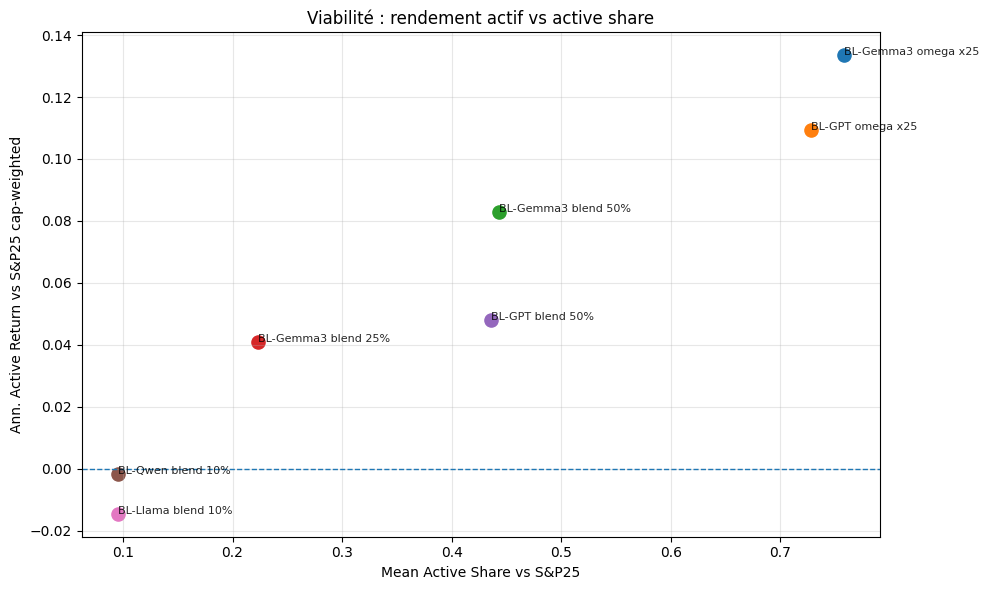

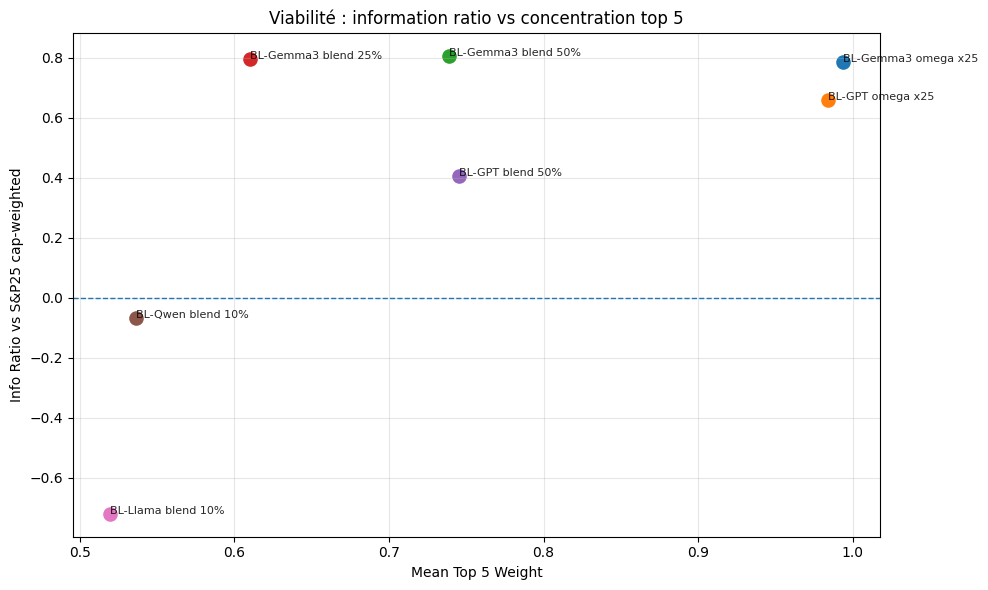

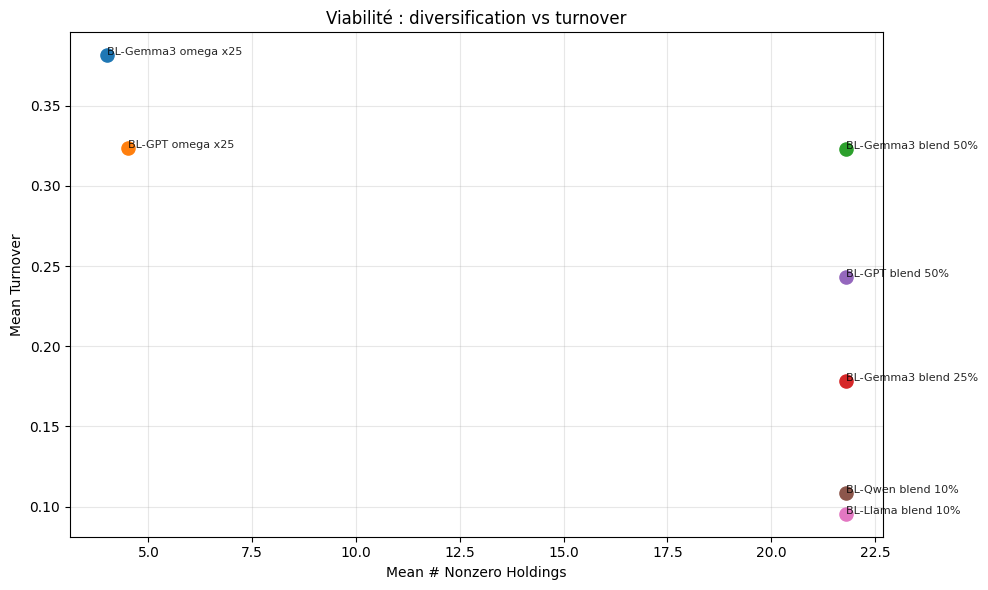

In [12]:

# ============================
# Graphiques de viabilité : rendement actif vs concentration / active share
# ============================

import matplotlib.pyplot as plt
import numpy as np

plot_df = bl_viability_summary.copy()

x_col = "Mean Active Share vs S&P25"
y_col = f"Ann. Active Return vs {BENCHMARK_NAME}"

if x_col in plot_df.columns and y_col in plot_df.columns:
    plt.figure(figsize=(10, 6))
    for name, row in plot_df.iterrows():
        plt.scatter(row[x_col], row[y_col], s=90)
        plt.annotate(name, (row[x_col], row[y_col]), fontsize=8, alpha=0.85)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Viabilité : rendement actif vs active share")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

x_col = "Mean Top 5 Weight"
y_col = f"Info Ratio vs {BENCHMARK_NAME}"

if x_col in plot_df.columns and y_col in plot_df.columns:
    plt.figure(figsize=(10, 6))
    for name, row in plot_df.iterrows():
        plt.scatter(row[x_col], row[y_col], s=90)
        plt.annotate(name, (row[x_col], row[y_col]), fontsize=8, alpha=0.85)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Viabilité : information ratio vs concentration top 5")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

x_col = "Mean # Nonzero Holdings"
y_col = "Mean Turnover"

if x_col in plot_df.columns and y_col in plot_df.columns:
    plt.figure(figsize=(10, 6))
    for name, row in plot_df.iterrows():
        plt.scatter(row[x_col], row[y_col], s=90)
        plt.annotate(name, (row[x_col], row[y_col]), fontsize=8, alpha=0.85)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Viabilité : diversification vs turnover")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

